In [ ]:
#Etap:Configuration de l'environnement

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

plt.style.use('default')
sns.set_palette("husl")
np.random.seed(42)

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


In [ ]:
#Etap1:Chargement des Données

In [ ]:

df = pd.read_csv('diabetic_data.csv')
ids_mapping = pd.read_csv('IDS_mapping.csv')

print(f"Dimensions du dataset : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'diabetic_data.csv'

In [ ]:
#Etap2:Exploration(EDA)

In [ ]:

# Informations générales
print("=" * 50)
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
print(df.info())

print("\nStatistiques descriptives (colonnes numériques):")
print(df.describe())

INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non

In [ ]:
#Distribution de la variable cible
print("Distribution de 'readmitted':")
print(df['readmitted'].value_counts())
print(f"\nPourcentages:")
print(df['readmitted'].value_counts(normalize=True).round(3) * 100)

Distribution de 'readmitted':
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Pourcentages:
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


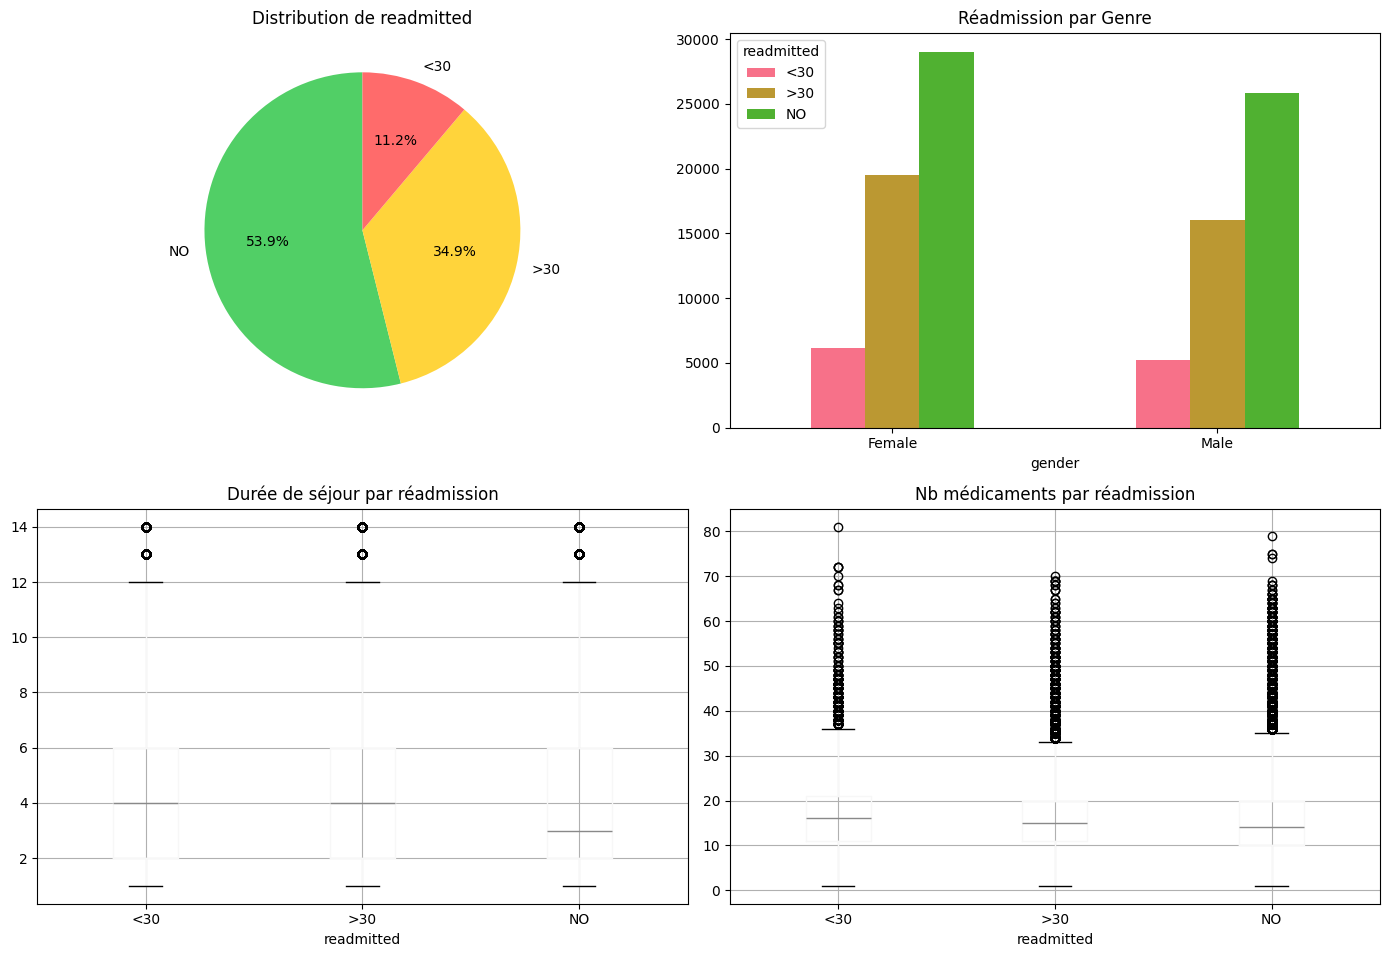

In [ ]:
# Visualisation EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution cible
counts = df['readmitted'].value_counts()
axes[0, 0].pie(counts, labels=counts.index, autopct='%1.1f%%',
               colors=['#51cf66', '#ffd43b', '#ff6b6b'], startangle=90)
axes[0, 0].set_title('Distribution de readmitted')

# 2. Réadmission par genre
df_gender = df[df['gender'].isin(['Male', 'Female'])]
gender_readm = df_gender.groupby(['gender', 'readmitted']).size().unstack(fill_value=0)
gender_readm.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Réadmission par Genre')
axes[0, 1].tick_params(axis='x', rotation=0)

# 3. Durée séjour vs réadmission
df.boxplot(column='time_in_hospital', by='readmitted', ax=axes[1, 0])
axes[1, 0].set_title('Durée de séjour par réadmission')
axes[1, 0].set_xlabel('readmitted')

# 4. Nombre de médicaments vs réadmission
df.boxplot(column='num_medications', by='readmitted', ax=axes[1, 1])
axes[1, 1].set_title('Nb médicaments par réadmission')
axes[1, 1].set_xlabel('readmitted')

plt.tight_layout()
plt.suptitle('')
plt.show()

In [ ]:
#Etap3:Nettoyage de Données

In [ ]:

# Remplacer '?' par NaN
df.replace('?', np.nan, inplace=True)

# Vérification valeurs manquantes
total = len(df)
missing = df.isnull().sum()
pct = (missing / total * 100).round(2)
result = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': pct})
result = result[result['Manquants'] > 0].sort_values('Pourcentage (%)', ascending=False)
print("Colonnes avec valeurs manquantes:")
print(result)

Colonnes avec valeurs manquantes:
                   Manquants  Pourcentage (%)
weight                 98569            96.86
max_glu_serum          96420            94.75
A1Cresult              84748            83.28
medical_specialty      49949            49.08
payer_code             40256            39.56
race                    2273             2.23
diag_3                  1423             1.40
diag_2                   358             0.35
diag_1                    21             0.02


In [ ]:
# Supprimer colonnes avec > 50% valeurs manquantes
cols_to_drop_missing = ['weight', 'max_glu_serum', 'A1Cresult']
df.drop(columns=cols_to_drop_missing, inplace=True)
print(f"✅ Colonnes supprimées (>50% NaN): {cols_to_drop_missing}")

# Supprimer colonnes identifiants (inutiles pour ML)
df.drop(columns=['encounter_id', 'patient_nbr'], inplace=True)
print("✅ Colonnes identifiants supprimées: encounter_id, patient_nbr")

# Supprimer colonnes avec une seule valeur unique
cols_one_val = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=cols_one_val, inplace=True)
print(f"✅ Colonnes à valeur unique supprimées: {cols_one_val}")

print(f"\nDimensions après nettoyage: {df.shape}")

✅ Colonnes supprimées (>50% NaN): ['weight', 'max_glu_serum', 'A1Cresult']
✅ Colonnes identifiants supprimées: encounter_id, patient_nbr
✅ Colonnes à valeur unique supprimées: ['examide', 'citoglipton']

Dimensions après nettoyage: (101766, 43)


In [ ]:
# Remplir les valeurs manquantes restantes
# - Numérique  → médiane
# - Catégoriel → mode

cols_with_nan = df.columns[df.isnull().sum() > 0].tolist()

for col in cols_with_nan:
    if df[col].dtype in ['int64', 'float64']:
        val = df[col].median()
        df[col] = df[col].fillna(val)
        print(f"[NUMÉRIQUE]   {col} → médiane = {val}")
    else:
        val = df[col].mode()[0]
        df[col] = df[col].fillna(val)
        print(f"[CATÉGORIEL]  {col} → mode = '{val}'")

print(f"\n✅ Valeurs manquantes restantes : {df.isnull().sum().sum()}")

[CATÉGORIEL]  race → mode = 'Caucasian'
[CATÉGORIEL]  payer_code → mode = 'MC'
[CATÉGORIEL]  medical_specialty → mode = 'InternalMedicine'
[CATÉGORIEL]  diag_1 → mode = '428'
[CATÉGORIEL]  diag_2 → mode = '276'
[CATÉGORIEL]  diag_3 → mode = '250'

✅ Valeurs manquantes restantes : 0


In [ ]:
#Etape4:Transformation de la variable Cible

Distribution de la cible binaire:
readmitted_bin
0    90409
1    11357
Name: count, dtype: int64

Taux de réadmission <30j : 11.16%


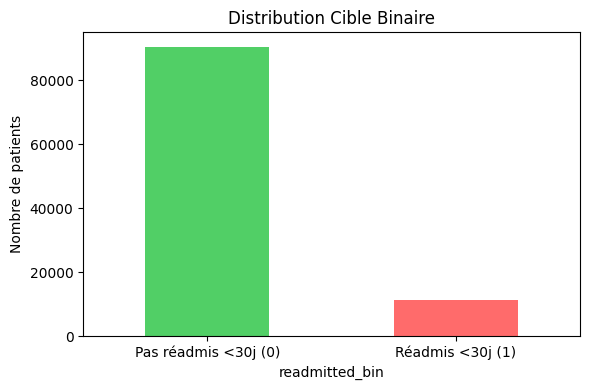

In [ ]:
# Classification binaire :
# 1 = réadmis en moins de 30 jours (cas critique)
# 0 = non réadmis OU réadmis après 30 jours

df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

print("Distribution de la cible binaire:")
print(df['readmitted_bin'].value_counts())
print(f"\nTaux de réadmission <30j : {df['readmitted_bin'].mean():.2%}")

# Visualisation
plt.figure(figsize=(6, 4))
df['readmitted_bin'].value_counts().plot(kind='bar', color=['#51cf66', '#ff6b6b'])
plt.title('Distribution Cible Binaire')
plt.xticks([0, 1], ['Pas réadmis <30j (0)', 'Réadmis <30j (1)'], rotation=0)
plt.ylabel('Nombre de patients')
plt.tight_layout()
plt.show()

In [ ]:
#Etap5:Encodage des variables Ctégorielles

In [ ]:
# Identifier les colonnes catégorielles
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Colonnes catégorielles à encoder ({len(cat_cols)}):")
print(cat_cols)

# LabelEncoder pour chaque colonne catégorielle
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\n✅ Encodage terminé")
print(f"\nDimensions finales : {df.shape}")
df.head()

Colonnes catégorielles à encoder (31):
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']

✅ Encodage terminé

Dimensions finales : (101766, 43)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_bin
0,2,0,0,6,25,1,1,7,37,41,...,0,1,1,0,0,0,0,1,0,0
1,2,0,1,1,1,7,3,7,18,59,...,0,3,1,0,0,0,0,0,1,0
2,0,0,2,1,1,7,2,7,18,11,...,0,1,1,0,0,0,0,1,1,0
3,2,1,3,1,1,7,2,7,18,44,...,0,3,1,0,0,0,0,0,1,0
4,2,1,4,1,1,7,1,7,18,51,...,0,2,1,0,0,0,0,0,1,0


In [ ]:
#Etap 6 :Séparation Features/Cible+Train/Test Split

In [ ]:
# Séparation X (features) et y (cible)
X = df.drop(columns=['readmitted_bin'])
y = df['readmitted_bin']

print(f"X (features) : {X.shape}")
print(f"y (cible)    : {y.shape}")

# Split Train/Test : 80% / 20%  (stratifié pour garder l'équilibre des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape} | Test : {X_test.shape}")
print(f"Taux cible train : {y_train.mean():.2%}")
print(f"Taux cible test  : {y_test.mean():.2%}")

X (features) : (101766, 42)
y (cible)    : (101766,)

Train : (81412, 42) | Test : (20354, 42)
Taux cible train : 11.16%
Taux cible test  : 11.16%


In [ ]:
#Etape 7: Pipline Scikit-learn(Normalisation+Modèle)

In [ ]:
# Création du pipeline : StandardScaler + RandomForestClassifier
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Entraînement
pipeline.fit(X_train, y_train)

print("✅ Modèle entraîné avec succès")
print(pipeline)

✅ Modèle entraîné avec succès
Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))])


In [ ]:
#Etape 8: Evaluation du Modèle

In [ ]:
# Prédictions
y_pred = pipeline.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, pipeline.predict(X_train))
acc_test  = accuracy_score(y_test, y_pred)

print(f"Accuracy Train : {acc_train:.4f}")
print(f"Accuracy Test  : {acc_test:.4f}")

print("\nRapport de Classification:")
print(classification_report(y_test, y_pred, target_names=['Non réadmis <30j', 'Réadmis <30j']))

Accuracy Train : 1.0000
Accuracy Test  : 0.8892

Rapport de Classification:
                  precision    recall  f1-score   support

Non réadmis <30j       0.89      1.00      0.94     18083
    Réadmis <30j       0.71      0.01      0.02      2271

        accuracy                           0.89     20354
       macro avg       0.80      0.51      0.48     20354
    weighted avg       0.87      0.89      0.84     20354



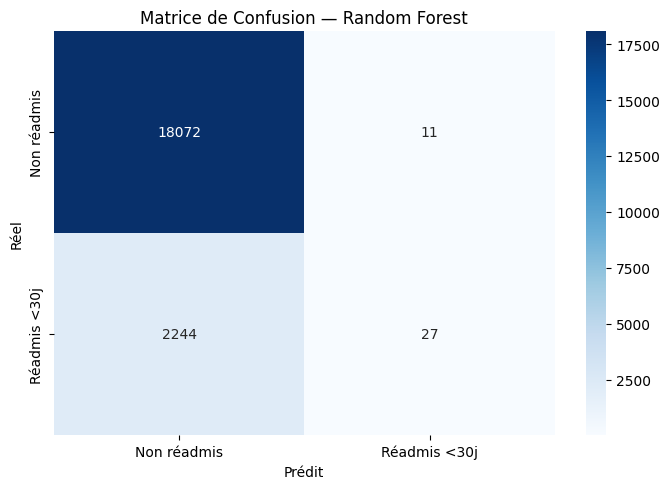

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non réadmis', 'Réadmis <30j'],
            yticklabels=['Non réadmis', 'Réadmis <30j'])
plt.title('Matrice de Confusion — Random Forest')
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.tight_layout()
plt.show()

In [ ]:
#Etap 9:Comparaison de Plusieurs Modèles

Logistic Regression       → Train: 0.8882 | Test: 0.8883
Decision Tree             → Train: 1.0000 | Test: 0.7989
Random Forest             → Train: 1.0000 | Test: 0.8892


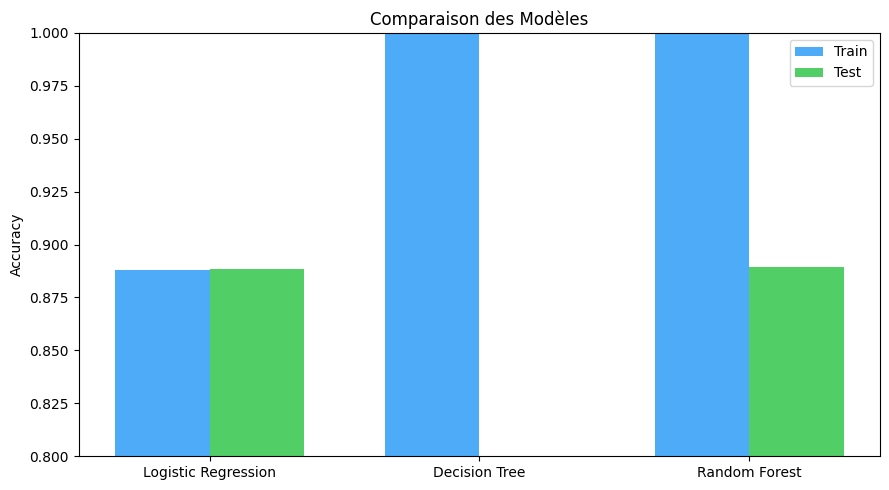


              Modèle  Train Accuracy  Test Accuracy
Logistic Regression          0.8882         0.8883
      Decision Tree          1.0000         0.7989
      Random Forest          1.0000         0.8892


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, pipe.predict(X_train))
    acc_te = accuracy_score(y_test,  pipe.predict(X_test))
    results.append({'Modèle': name, 'Train Accuracy': round(acc_tr, 4), 'Test Accuracy': round(acc_te, 4)})
    print(f"{name:25s} → Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

results_df = pd.DataFrame(results)

# Visualisation
plt.figure(figsize=(9, 5))
x = np.arange(len(results_df))
width = 0.35
plt.bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='#4dabf7')
plt.bar(x + width/2, results_df['Test Accuracy'],  width, label='Test',  color='#51cf66')
plt.xticks(x, results_df['Modèle'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Comparaison des Modèles')
plt.legend()
plt.tight_layout()
plt.show()

print("\n", results_df.to_string(index=False))

In [ ]:
# ============================================================
# Étape 9 : Comparaison de Plusieurs Modèles (cellule complète)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB

# ── Chargement et préparation des données ───────────────────
df = pd.read_csv('diabetic_data.csv')
df.replace('?', np.nan, inplace=True)

# Suppression colonnes inutiles
df.drop(columns=['weight', 'max_glu_serum', 'A1Cresult',
                 'encounter_id', 'patient_nbr'], inplace=True)
cols_one = [c for c in df.columns if df[c].nunique() <= 1]
df.drop(columns=cols_one, inplace=True)

# Remplissage valeurs manquantes
for col in df.columns[df.isnull().sum() > 0]:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Variable cible binaire
df['readmitted_bin'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

# Encodage
for col in df.select_dtypes(include=['object', 'str']).columns:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Split
X = df.drop(columns=['readmitted_bin'])
y = df['readmitted_bin']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Données prêtes — Train: {X_train.shape} | Test: {X_test.shape}")

# ── Définition des modèles ───────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'         : GaussianNB(),
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'SVM (Linear)'        : LinearSVC(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

# ── Entraînement et évaluation ───────────────────────────────
results = []
for name, model in models.items():
    start = time.time()
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    pipe.fit(X_train, y_train)
    duration = round(time.time() - start, 2)
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    acc_test  = accuracy_score(y_test,  pipe.predict(X_test))
    results.append({'Modèle': name, 'Train Accuracy': round(acc_train, 4),
                    'Test Accuracy': round(acc_test, 4), 'Temps (s)': duration})
    print(f"{name:25s} → Train: {acc_train:.4f} | Test: {acc_test:.4f} | {duration}s")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n", results_df.to_string(index=False))

# ── Visualisation ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df['Modèle'], results_df['Train Accuracy'],
             height=0.4, label='Train', color='#4dabf7', align='edge')
axes[0].barh(results_df['Modèle'], results_df['Test Accuracy'],
             height=-0.4, label='Test', color='#51cf66', align='edge')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Train vs Test Accuracy')
axes[0].legend()
axes[0].set_xlim(0.7, 1.01)

axes[1].barh(results_df['Modèle'], results_df['Temps (s)'], color='#ffd43b')
axes[1].set_xlabel('Temps (secondes)')
axes[1].set_title("Temps d'entraînement")

plt.tight_layout()
plt.show()

# ── Meilleur modèle ──────────────────────────────────────────
best = results_df.iloc[0]
print(f"\n🏆 Meilleur modèle : {best['Modèle']}")
print(f"   Test Accuracy  : {best['Test Accuracy']}")
print(f"   Temps          : {best['Temps (s)']}s")

FileNotFoundError: [Errno 2] No such file or directory: 'diabetic_data.csv'

In [ ]:
#Etape 10: Importance des Feautres

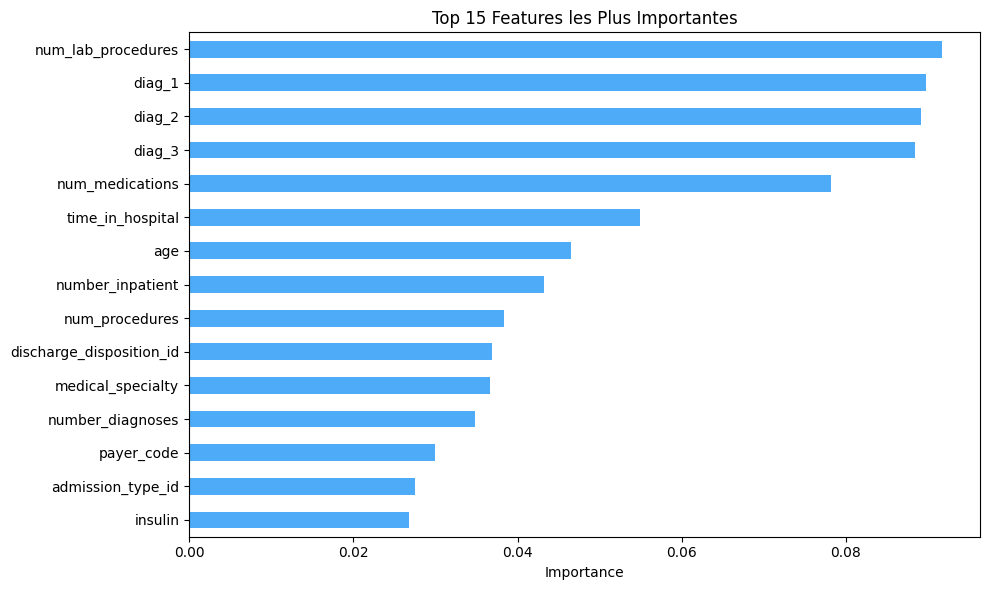


Top 15 features:
num_lab_procedures          0.091736
diag_1                      0.089746
diag_2                      0.089088
diag_3                      0.088456
num_medications             0.078115
time_in_hospital            0.054965
age                         0.046525
number_inpatient            0.043205
num_procedures              0.038371
discharge_disposition_id    0.036877
medical_specialty           0.036597
number_diagnoses            0.034766
payer_code                  0.029917
admission_type_id           0.027570
insulin                     0.026739
dtype: float64


In [ ]:
# Extraire le RandomForest du pipeline
rf_model = pipeline.named_steps['model']

importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#4dabf7')
plt.gca().invert_yaxis()
plt.title('Top 15 Features les Plus Importantes')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(importances)